In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

sns.set(style="whitegrid")


In [5]:
# =====================================================
# LOAD DATA
# =====================================================

pred_df = pd.read_csv("/projects/e32998/STAT390_Winter2026/Team2/Code/MIL_trainer/results/run_20260219_095000/predictions.csv")
attn_df = pd.read_csv("/projects/e32998/STAT390_Winter2026/Team2/Code/MIL_trainer/results/run_20260219_095000/attention_analysis/top_effective_patches_per_case_100.0pct.csv")


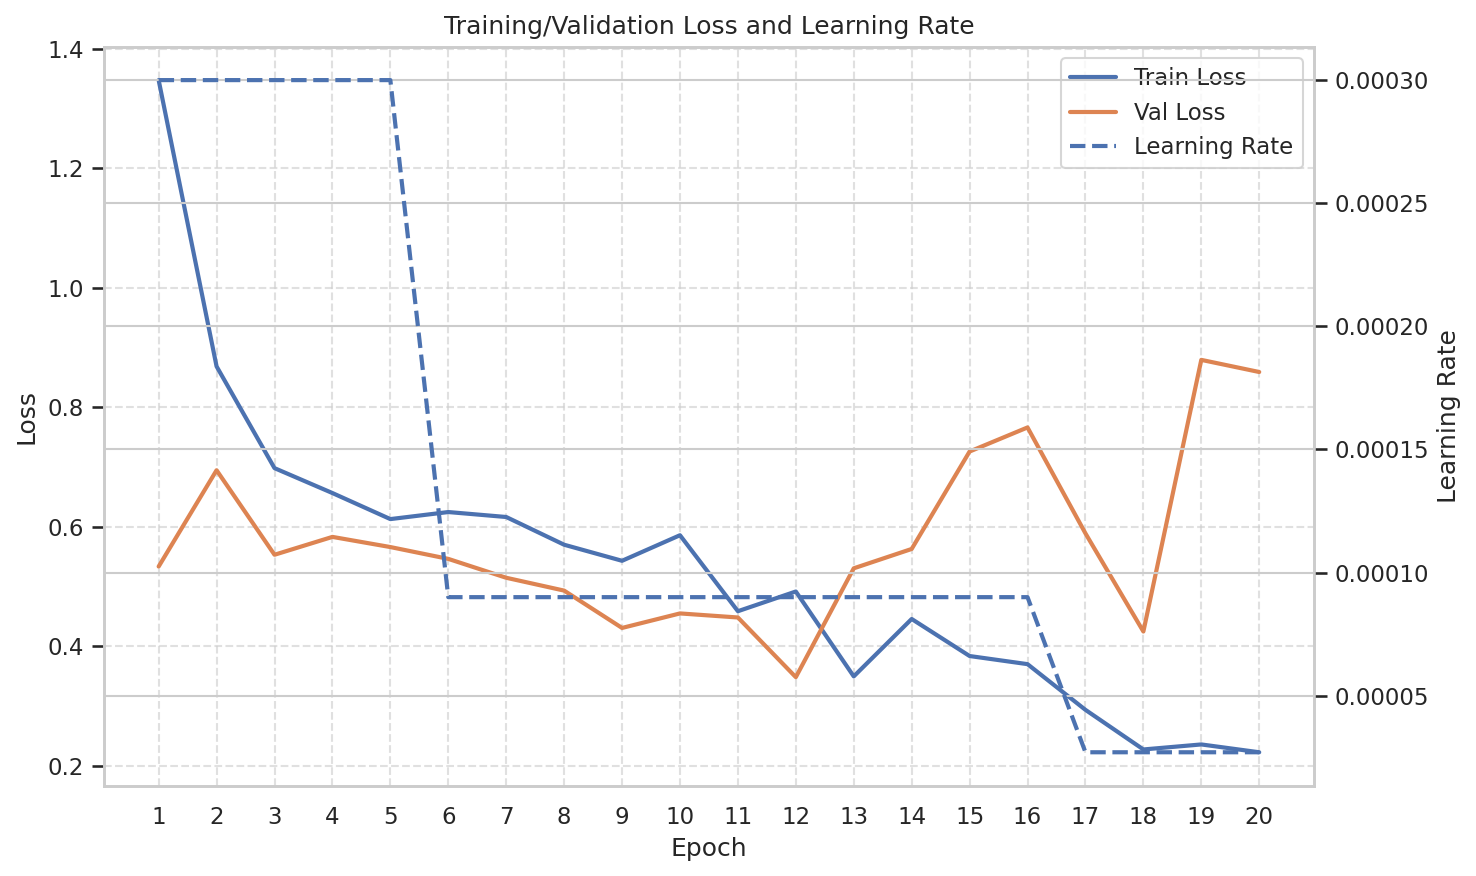

In [6]:
import re
import matplotlib.pyplot as plt

log_path = "/projects/e32998/STAT390_Winter2026/Team2/Code/MIL_trainer/logs/training_logs_9122489.log"

train_losses = []
val_losses = []
lrs = []

# Patterns to extract losses and learning rate
loss_pattern = re.compile(r"Train Loss:\s*([0-9eE\.\-]+),\s*Val Loss:\s*([0-9eE\.\-]+)")
lr_pattern = re.compile(r"Epoch\s*\d+/\d+\s*\(LR:\s*([0-9eE\.\-]+)\)")

with open(log_path, "r") as f:
    for line in f:
        # Extract learning rate
        lr_match = lr_pattern.search(line)
        if lr_match:
            lrs.append(float(lr_match.group(1)))

        # Extract train/val losses
        loss_match = loss_pattern.search(line)
        if loss_match:
            train_losses.append(float(loss_match.group(1)))
            val_losses.append(float(loss_match.group(2)))

# Sanity check
if len(train_losses) == 0:
    raise ValueError("No Train/Val loss found. Check log format / pattern.")

epochs = list(range(1, len(train_losses) + 1))


fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# Plot train and validation loss
ax1.plot(epochs, train_losses, label="Train Loss", linewidth=2)
ax1.plot(epochs, val_losses, label="Val Loss", linewidth=2)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_xticks(epochs)
ax1.grid(True, linestyle="--", alpha=0.6)

ax2 = ax1.twinx()
ax2.plot(epochs, lrs, label="Learning Rate", linewidth=2, linestyle ='--')
ax2.set_ylabel("Learning Rate")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Training/Validation Loss and Learning Rate")
plt.tight_layout()
plt.show()


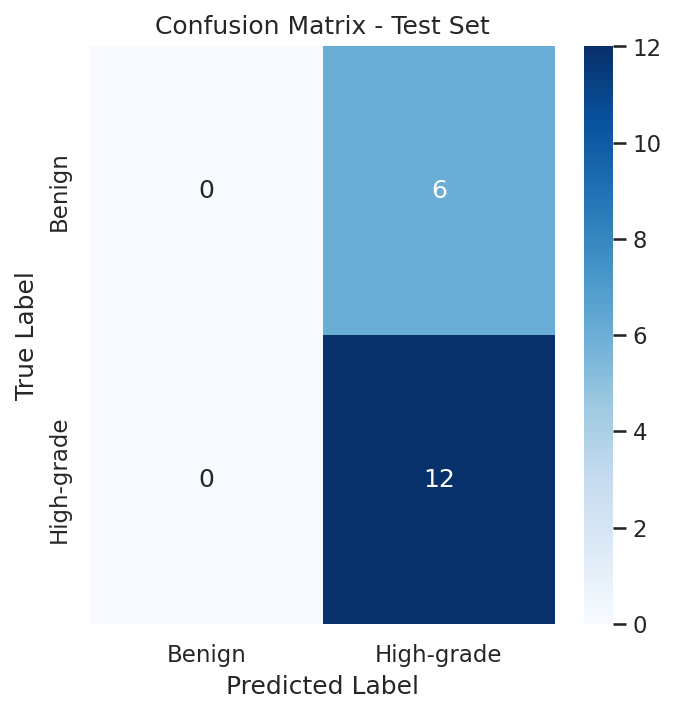

In [7]:
# =====================================================
# 2. CONFUSION MATRIX
# =====================================================


y_true = pred_df["true_label"]
y_pred = pred_df["predicted_label"]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Class labels
class_labels = ["Benign", "High-grade"]

plt.figure(figsize=(5,5), dpi=150)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")
plt.show()



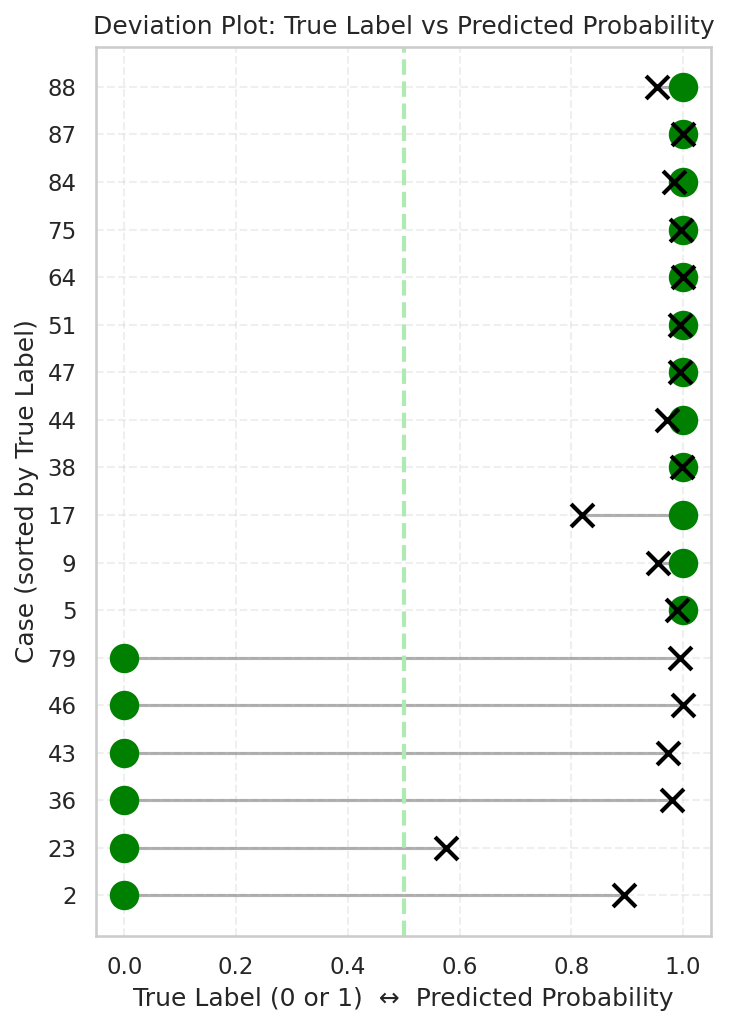

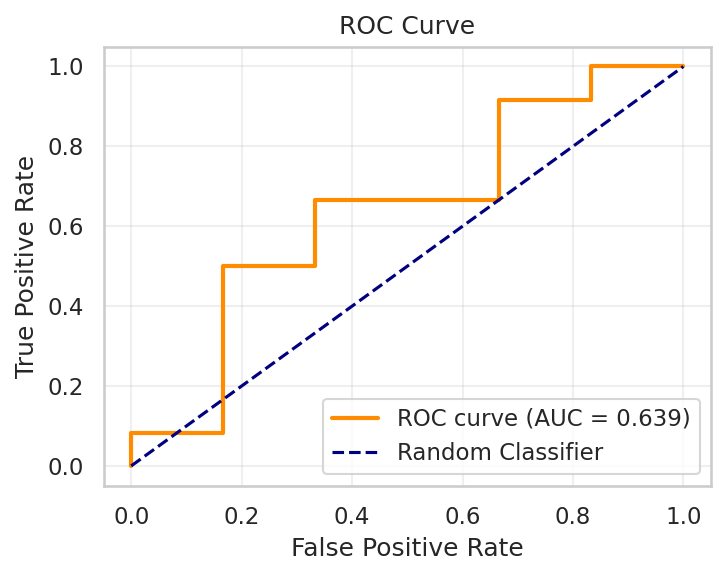


Computed AUC = 0.639


In [8]:
# =====================================================
# 3. DEVIATION PLOT
# =====================================================


pred_df_sorted = pred_df.sort_values(["true_label", "case_id"]).reset_index(drop=True)
pred_df_sorted["case_str"] = pred_df_sorted["case_id"].astype(str)

# -----------------------------------------------------
# 1. Deviation Plot: True Label vs Predicted Probability
# -----------------------------------------------------
plt.figure(figsize=(5,7), dpi=150)

for i, row in pred_df_sorted.iterrows():
    # connecting line
    plt.plot(
        [row["true_label"], row["prob_high_grade"]],
        [i, i],
        color="gray",
        alpha=0.6,
        linewidth=1.5
    )
    # true label = green circle
    plt.scatter(
        row["true_label"], i,
        color="green",
        s=200,
        marker="o",
        edgecolor="black",
        linewidth=0,
        zorder=3
    )
    # predicted probability = black X
    plt.scatter(
        row["prob_high_grade"], i,
        color="black",
        s=120,
        marker="x",
        linewidths=2,
        zorder=4
    )

plt.yticks(range(len(pred_df_sorted)), pred_df_sorted["case_str"])
plt.axvline(0.5, color="#ADEBB3", linestyle="--", linewidth=2, label="Decision Threshold (0.5)")
plt.xlabel("True Label (0 or 1)  ↔  Predicted Probability")
plt.ylabel("Case (sorted by True Label)")
plt.title("Deviation Plot: True Label vs Predicted Probability")
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 2. ROC / AUC Curve
# -----------------------------------------------------
fpr, tpr, thresholds = roc_curve(pred_df["true_label"], pred_df["prob_high_grade"])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4), dpi=150)
plt.plot(
    fpr, tpr,
    color='darkorange',
    lw=2,
    label=f'ROC curve (AUC = {roc_auc:.3f})'
)
plt.plot(
    [0, 1], [0, 1],
    color='navy',
    lw=1.5,
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nComputed AUC = {roc_auc:.3f}")


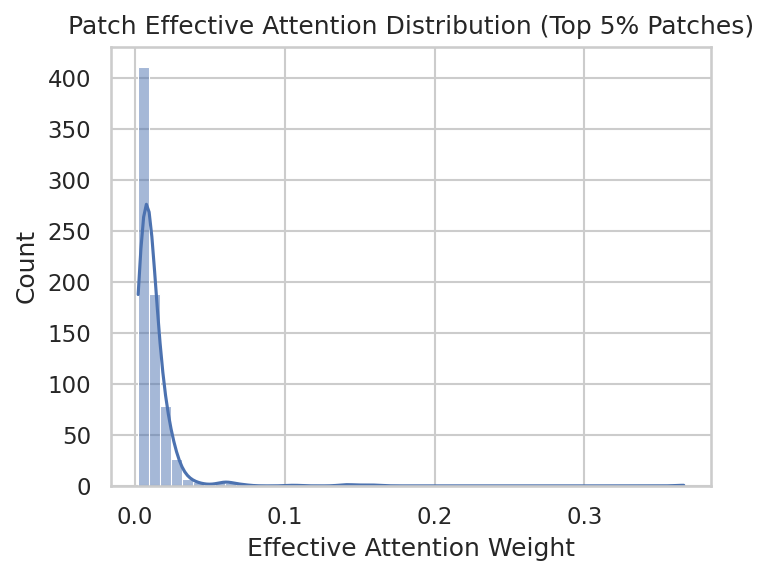

In [16]:
# =====================================================
# 4. EFFECTIVE ATTENTION DISTRIBUTION (PATCH)
# =====================================================

attn_df = pd.read_csv("/projects/e32998/STAT390_Winter2026/Team2/Code/MIL_trainer/results/run_20260218_220625/attention_analysis/top_effective_patches_per_case_5.0pct.csv")

plt.figure(figsize=(5,4), dpi=150)
sns.histplot(attn_df["effective_weight"], bins=50, kde=True)
plt.xlabel("Effective Attention Weight")
plt.title("Patch Effective Attention Distribution (Top 5% Patches)")
plt.tight_layout()
plt.show()



Total patches: 14709
Unique slices: 52


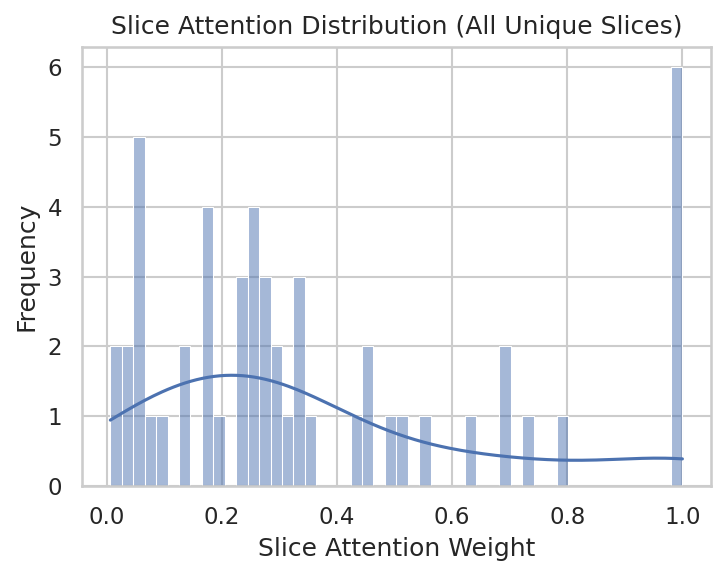

In [10]:
# =====================================================
# 5. SLICE ATTENTION DISTRIBUTION
# =====================================================

slice_df = attn_df.drop_duplicates(subset=["case_id", "slice_idx"])

print("Total patches:", len(attn_df))
print("Unique slices:", len(slice_df))

plt.figure(figsize=(5,4), dpi=150)

sns.histplot(
    slice_df["slice_attn_weight"],
    bins=50,
    kde=True
)

plt.xlabel("Slice Attention Weight")
plt.ylabel("Frequency")
plt.title("Slice Attention Distribution (All Unique Slices)")

plt.tight_layout()
plt.show()


Unique stains: 52


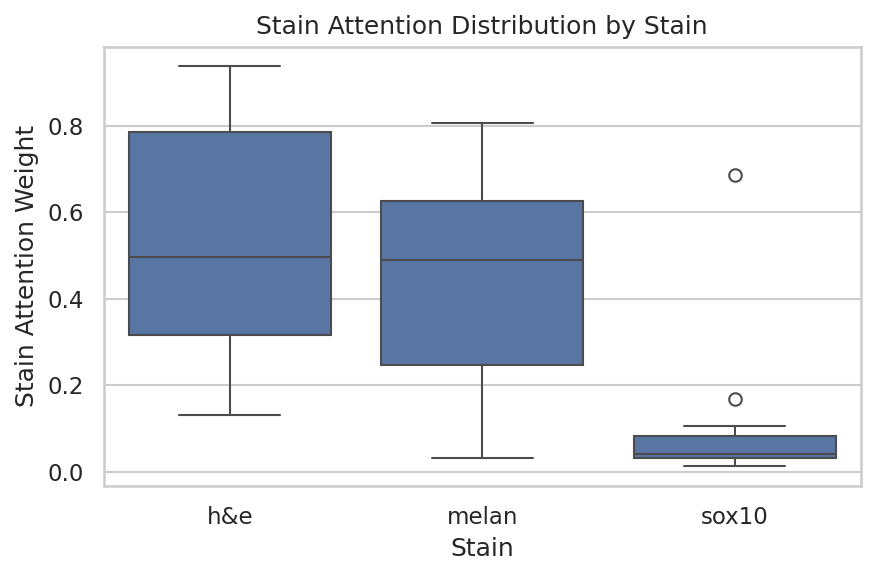

In [11]:
# =====================================================
# 6. STAIN ATTENTION DISTRIBUTION
# =====================================================

stain_df = attn_df.drop_duplicates(subset=["case_id", "stain"])

print("Unique stains:", len(stain_df))

plt.figure(figsize=(6,4), dpi=150)

sns.boxplot(
    data=stain_df,
    x="stain",
    y="stain_attn_weight"
)

plt.xlabel("Stain")
plt.ylabel("Stain Attention Weight")
plt.title("Stain Attention Distribution by Stain")

plt.tight_layout()
plt.show()

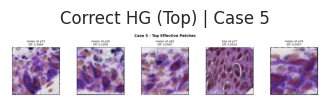

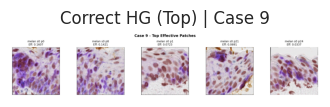

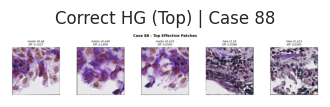

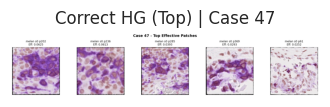

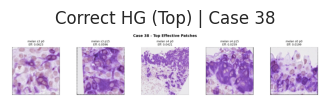

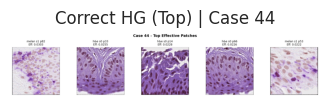

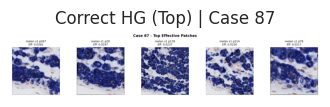

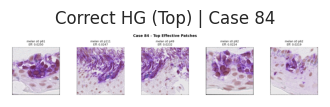

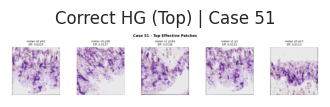

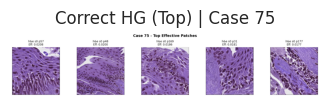

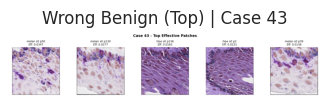

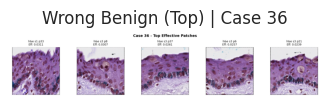

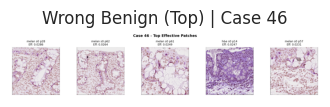

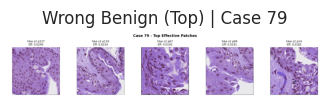

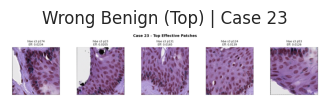

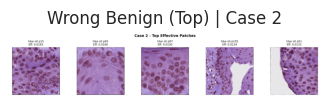

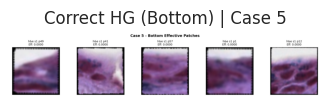

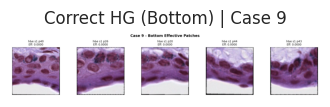

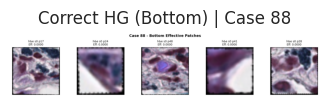

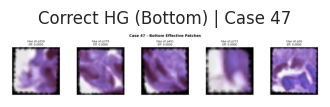

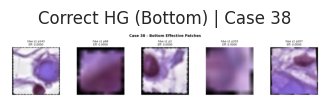

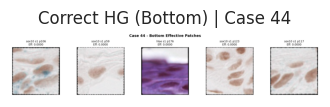

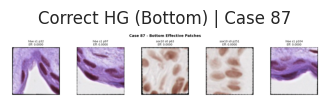

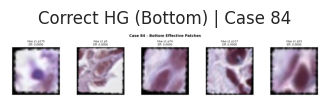

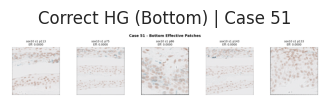

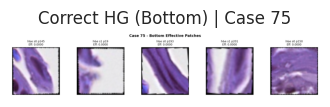

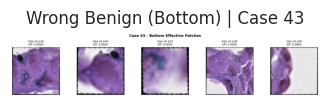

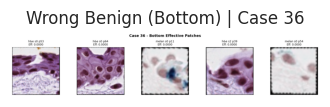

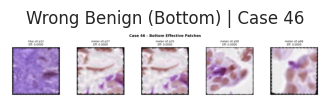

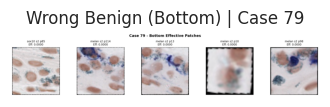

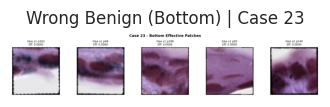

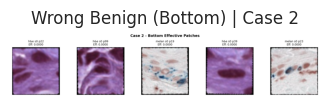

In [ ]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt


# attn_df already has true_label and pred_label
merged = attn_df.copy()
merged["correct"] = merged["true_label"] == merged["pred_label"]



case_summary = (
    merged
    .groupby(["case_id", "true_label", "correct"])["effective_weight"]
    .max()
    .reset_index(name="max_effective")
)



def top_k_cases(df, label, correct, k=10):
    subset = df[
        (df["true_label"] == label) &
        (df["correct"] == correct)
    ]
    
    return subset.sort_values(
        "max_effective",
        ascending=False
    ).head(k)


top_correct_benign = top_k_cases(case_summary, label=0, correct=True)
top_correct_hg     = top_k_cases(case_summary, label=1, correct=True)
top_wrong_benign   = top_k_cases(case_summary, label=0, correct=False)
top_wrong_hg       = top_k_cases(case_summary, label=1, correct=False)


base_dir = "/projects/e32998/STAT390_Winter2026/Team2/Code/MIL_trainer/results/run_20260218_220625/attention_analysis/case_effective_patches"

def show_case_pngs(df, top=True, title_prefix=""):
    for _, row in df.iterrows():
        case_id = row["case_id"]
        
        filename = (
            f"case_{case_id}_top_effective_patches.png"
            if top
            else f"case_{case_id}_bottom_effective_patches.png"
        )
        
        img_path = os.path.join(base_dir, filename)
        
        if not os.path.exists(img_path):
            print(f"Missing file: {img_path}")
            continue
        
        img = Image.open(img_path)
        
        plt.figure(figsize=(4,4))
        plt.imshow(img)
        plt.title(f"{title_prefix} | Case {case_id}")
        plt.axis("off")
        plt.show()


# TOP PATCHES
show_case_pngs(top_correct_benign, top=True,  title_prefix="Correct Benign (Top)")
show_case_pngs(top_correct_hg,     top=True,  title_prefix="Correct HG (Top)")
show_case_pngs(top_wrong_benign,   top=True,  title_prefix="Wrong Benign (Top)")
show_case_pngs(top_wrong_hg,       top=True,  title_prefix="Wrong HG (Top)")

# BOTTOM PATCHES
show_case_pngs(top_correct_benign, top=False, title_prefix="Correct Benign (Bottom)")
show_case_pngs(top_correct_hg,     top=False, title_prefix="Correct HG (Bottom)")
show_case_pngs(top_wrong_benign,   top=False, title_prefix="Wrong Benign (Bottom)")
show_case_pngs(top_wrong_hg,       top=False, title_prefix="Wrong HG (Bottom)")